In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import calc_op_em as coe
import h5py
from tqdm import tqdm

In [2]:
cube = h5py.File('/dat/milic/SUSI_modeling/extended_off_limb_cube_paper_angle_80.h5','r')

In [3]:
T = cube['Temperature']

In [4]:
T.shape

(1024, 12500, 401)

In [5]:
Tt = T[:,:1024,:]

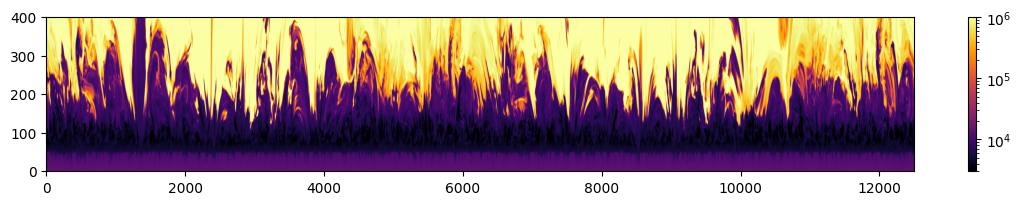

In [6]:
plt.figure(figsize=[14,2])
plt.imshow(T[0,:,:].T, origin='lower',cmap='inferno', aspect='auto', norm='log',vmin=3E3, vmax=1E6)
plt.colorbar()

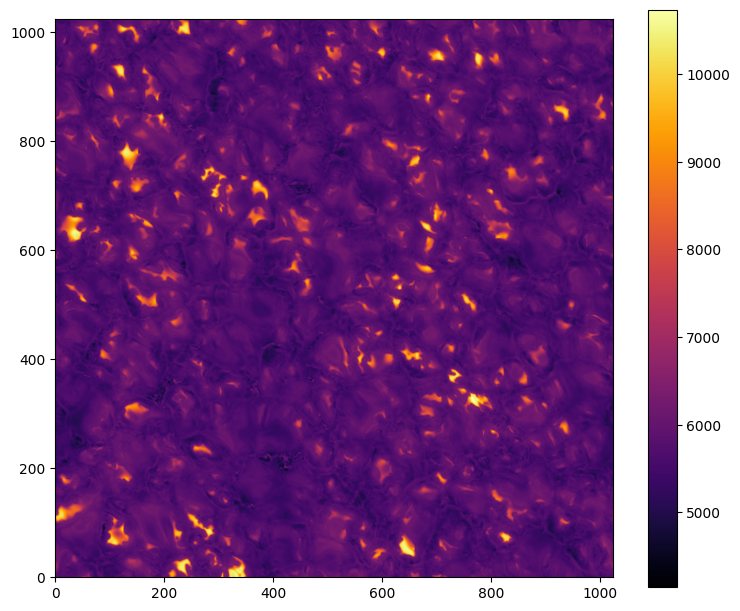

In [7]:
plt.figure(figsize=[9,7.5])
plt.imshow(Tt[:,:,50].T, origin='lower',cmap='inferno')
plt.colorbar()

In [8]:
## Test the curvature a little bit:

def create_curved_grid(z_index):
    N_steps = 10001
    
    s = (np.arange(N_steps) - N_steps // 2) * 24.0 # km    
    R_at_the_tangent = 696.0E3 + z_index * 24.0 # km
    
    angle = np.arctan(s / R_at_the_tangent)
    y = R_at_the_tangent * angle
    z = z_index * 24.0 + np.sqrt(s**2 + R_at_the_tangent**2) - R_at_the_tangent
    
    return s, y, z

In [9]:
s, y, z = create_curved_grid(0)

In [10]:
print(z)

[10269.07053898 10264.99316899 10260.91659103 ... 10260.91659103
 10264.99316899 10269.07053898]


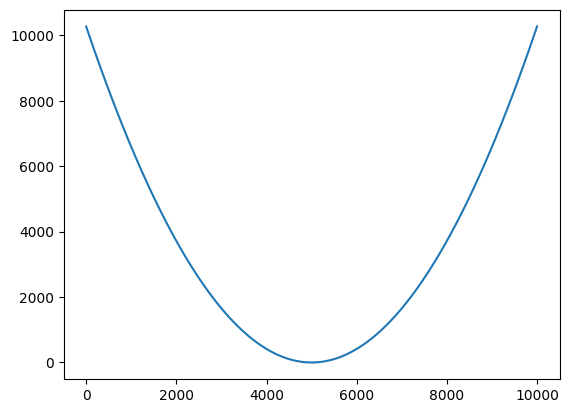

In [11]:
plt.plot(z)

In [12]:
# Now we want to extract one vertical slice, for example at i = 0
# Let's quickly repack:
i = 0


slice = []

# Let's make a ray of paramters:

for z in range(0, 401):
    param_ray = {
        'Temperature': cube['Temperature'][i,:,z],
        'Pressure': cube['Pressure'][i,:,z],
        'Electron_density': cube['Electron_density'][i,:,z],
        'LOS_velocity': cube['LOS_velocity'][i,:,z],
        'Population_lower_level': cube['Population_lower_level'][i,:,400-z]/1e6,
        'Population_upper_level': cube['Population_upper_level'][i,:,400-z]/1e6
    }
    slice.append(param_ray)

In [13]:
from scipy.interpolate import RegularGridInterpolator as rgi

def create_ray(slice, z_index):
    
    param_ray = 0
    
    # We need to create a grid of y, z values that traverses as it travels in the spherical geometry 
    # Then we bi-linearly interpolate where we can, and where we fall out - we just set zeros (or we don't even need anything)
    
    # Say that max possible lenght of this is N_steps 
    N_steps = 10001
    
    s = (np.arange(N_steps) - N_steps // 2) * 24.0 # km    
    R_at_the_tangent = 696.0E3 + z_index * 24.0 # km
    
    angle = np.arctan(s / R_at_the_tangent)
    y = R_at_the_tangent * angle
    z = z_index * 24.0 + np.sqrt(s**2 + R_at_the_tangent**2) - R_at_the_tangent
    
    # Then we just interpolate the slice to get the parameters at each point.
    NY = slice['Temperature'].shape[0]
    NZ = slice['Temperature'].shape[1]
    y_slice = (np.arange(NY) - NY // 2) * 24.0
    z_slice = (np.arange(NZ)) * 20.0
    
    # Let's use scipy's regular grid interpolatetor for this
    
    interpolator = rgi((y_slice, z_slice), slice['Temperature'], bounds_error=False, fill_value=0.0)
    T_interpolated = interpolator((y, z))
    interpolator = rgi((y_slice, z_slice), slice['Pressure'], bounds_error=False, fill_value=0.0)
    P_interpolated = interpolator((y, z))
    interpolator = rgi((y_slice, z_slice), slice['Electron_density'], bounds_error=False, fill_value=0.0)
    Ne_interpolated = interpolator((y, z))
    interpolator = rgi((y_slice, z_slice), slice['LOS_velocity'], bounds_error=False, fill_value=0.0)
    V_interpolated = interpolator((y, z))
    interpolator = rgi((y_slice, z_slice), slice['Population_lower_level'], bounds_error=False, fill_value=0.0)
    PopL_interpolated = interpolator((y, z))
    interpolator = rgi((y_slice, z_slice), slice['Population_upper_level'], bounds_error=False, fill_value=0.0)
    PopU_interpolated = interpolator((y, z))
    
    param_ray = {
        'Temperature': T_interpolated,
        'Pressure': P_interpolated,
        'Electron_density': Ne_interpolated,
        'LOS_velocity': V_interpolated,
        'Population_lower_level': PopL_interpolated,
        'Population_upper_level': PopU_interpolated
    }
    
    return param_ray

In [14]:
# First create a slice:
i=0
slice_test = {
    'Temperature': cube['Temperature'][i,:,:],
    'Pressure': cube['Pressure'][i,:,:],
    'Electron_density': cube['Electron_density'][i,:,:],
    'LOS_velocity': cube['LOS_velocity'][i,:,:],
    'Population_lower_level': cube['Population_lower_level'][i,:,:]/1e6,
    'Population_upper_level': cube['Population_upper_level'][i,:,:]/1e6}

In [15]:
myray = create_ray(slice_test, 100)

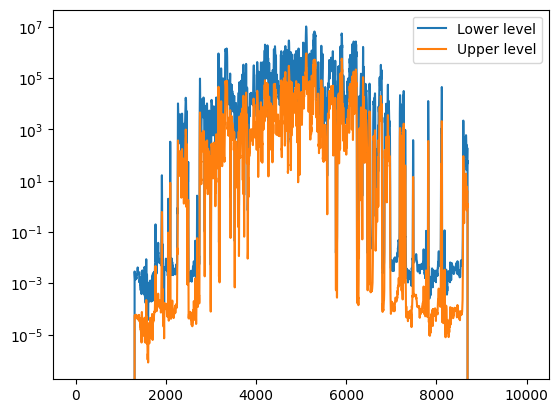

: 

In [ ]:
plt.semilogy(myray['Population_lower_level'], label='Lower level')
plt.semilogy(myray['Population_upper_level'], label='Upper level')
plt.legend()

In [26]:
def synth(param_ray, boundary, wavelengths):
    
    # This function synthesises the spectrum for a given atmospheric column.
    op, em = coe.calc_op_em(param_ray, ll, take_given_S=False)
    spectrum_temp, tau, CR = coe.simple_formal_solution(op, op, 24.0e5)
    spectrum = 1.0 - np.exp(-tau)
    return spectrum

In [27]:
ll = np.linspace(393.0, 393.6, 601) # in nm

In [28]:
I = synth(myray, 0, ll)

/home/milic/codes/offlimb_3D_modeling/calc_op_em.py:71: RuntimeWarning: invalid value encountered in divide
  nH_los = (Pgas_los / (const.k_B.cgs.value * T_los) - ne_los) * 0.9 #
/home/milic/codes/offlimb_3D_modeling/contop.py:142: RuntimeWarning: divide by zero encountered in divide
  nhi = nhtot / (1.0 + saha / ne)


IndexError: boolean index did not match indexed array along axis 0; size of axis is 601 but size of corresponding boolean axis is 10001

In [52]:
spectrum = np.zeros((len(slice), len(ll)))

for z in tqdm(range(len(slice))):

    op, em = coe.calc_op_em(slice[z], ll, take_given_S=False)
    spectrum_temp, tau, CR = coe.simple_formal_solution(op, op, 24.0e5)
    spectrum[z,:] = 1.0 - np.exp(-tau)

100%|██████████| 401/401 [07:51<00:00,  1.18s/it]


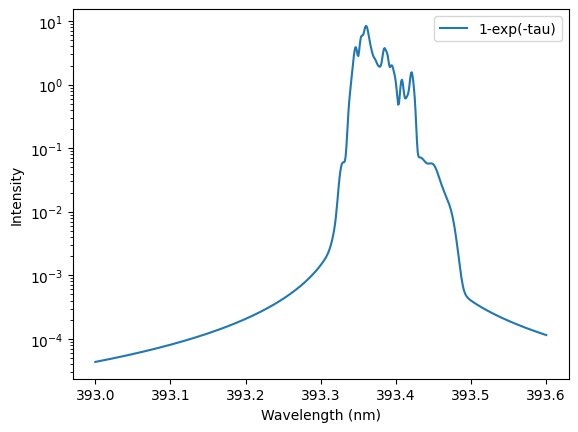

In [46]:
plt.semilogy(ll, tau, label='1-exp(-tau)')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity')
plt.legend()
plt.show()

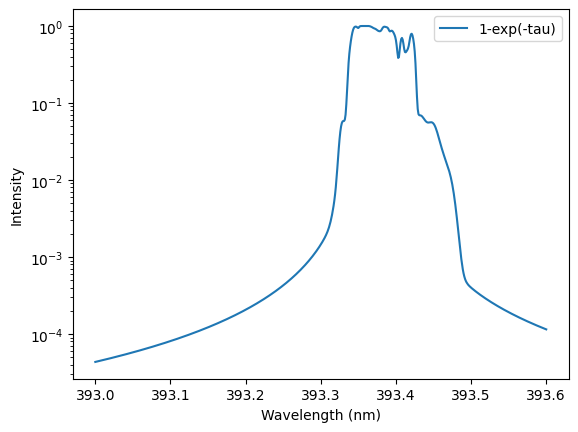

In [47]:
plt.semilogy(ll, 1-np.exp(-tau), label='1-exp(-tau)')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity')
plt.legend()
plt.show()

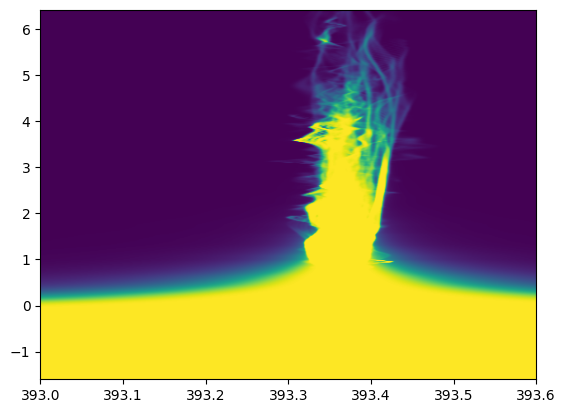

In [59]:
plt.imshow(spectrum, aspect='auto', extent=[ll[0], ll[-1], 0-1.6, len(slice)*0.02-1.6], origin='lower')

In [71]:
T = np.mean(cube['Temperature'][0,:,:], axis=(0))

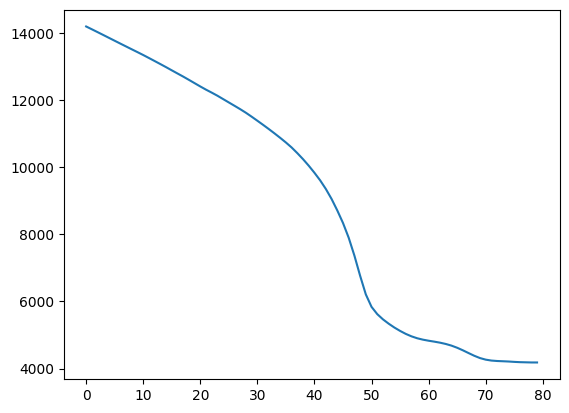

In [74]:
plt.plot(T[:80])